In [133]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
#ds = load_dataset("AzharAli05/Resume-Screening-Dataset")

In [134]:
#ds

In [135]:

"""""
df = ds["train"].to_pandas()  # or ds["test"] if it exists
df"""

'""\ndf = ds["train"].to_pandas()  # or ds["test"] if it exists\ndf'

In [136]:
# df["Resume"].iloc[0]

In [137]:
import pandas as pd
import matplotlib.pyplot as plt

In [138]:

df = pd.read_csv("C:\\Users\\DELL\\Desktop\\NLP_course\\Resume-Screening\\Resume_screening.csv")

In [139]:
df

,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...
3,E-commerce Specialist,Here's a professional resume for Patricia Gray...,select,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...
...,...,...,...,...,...
10169,Product Manager,Here's a sample resume for Diana Miller:\n\n**...,reject,Unsatisfactory references or background check.,Here is a comprehensive job description for a ...
10170,UI Engineer,Here's a sample resume for Grace Taylor:\n\n**...,reject,Lack of relevant skills or experience.,Here is a sample job description for a UI Engi...
10171,UI Engineer,Here's a sample resume for Hank Brown:\n\n**Ha...,select,Growth mindset and adaptability.,Here is a job description for a UI Engineer ro...
10172,Data Engineer,Here's a sample resume for Diana Wilson:\n\n**...,reject,Lack of relevant skills or experience.,Here is a comprehensive job description for a ...


In [140]:
df['Role'].value_counts()

Role
Data Scientist                  538
Software Engineer               480
Product Manager                 458
Data Engineer                   447
UI Engineer                     375
Data Analyst                    329
data engineer                   307
software engineer               307
product manager                 303
data scientist                  287
E-commerce Specialist           268
DevOps Engineer                 266
Machine Learning Engineer       265
Human Resources Specialist      262
Digital Marketing Specialist    260
Robotics Engineer               257
Cloud Architect                 254
Blockchain Developer            251
QA Engineer                     251
Mobile App Developer            247
Full Stack Developer            246
Database Administrator          243
Cloud Engineer                  240
Game Developer                  239
Content Writer                  238
AR/VR Developer                 237
Cybersecurity Analyst           234
UX Designer            

Total Unique Job Roles to Predict: 45

--- Distribution of Job Roles ---
Role
Data Scientist                  538
Software Engineer               480
Product Manager                 458
Data Engineer                   447
UI Engineer                     375
Data Analyst                    329
data engineer                   307
software engineer               307
product manager                 303
data scientist                  287
E-commerce Specialist           268
DevOps Engineer                 266
Machine Learning Engineer       265
Human Resources Specialist      262
Digital Marketing Specialist    260
Robotics Engineer               257
Cloud Architect                 254
Blockchain Developer            251
QA Engineer                     251
Mobile App Developer            247
Full Stack Developer            246
Database Administrator          243
Cloud Engineer                  240
Game Developer                  239
Content Writer                  238
AR/VR Developer       

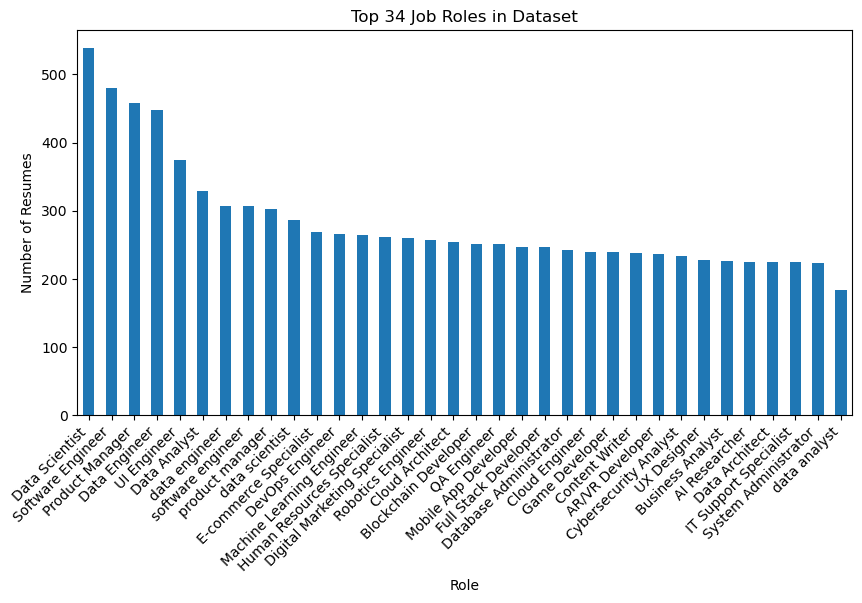

In [141]:
# Count the number of unique roles
unique_roles = df['Role'].nunique()
print(f"Total Unique Job Roles to Predict: {unique_roles}")

# Display the distribution of the roles
role_counts = df['Role'].value_counts()
print("\n--- Distribution of Job Roles ---")
print(role_counts)

# Optional: Plot the top 15 roles to visualize distribution
role_counts.head(34).plot(kind='bar', figsize=(10, 5))
plt.title("Top 34 Job Roles in Dataset")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45, ha='right')
plt.show()

In [142]:
# 1. Convert all roles to lowercase to fix casing duplicates
df['Cleaned_Role'] = df['Role'].str.lower().str.strip()

# 2. Merge overlapping titles 
role_mapping = {
    'ui engineer': 'ui/ux designer',
    'ui designer': 'ui/ux designer',
    'ux designer': 'ui/ux designer',
    'software developer': 'software engineer',
    'cybersecurity specialist': 'cybersecurity analyst',
    'hr specialist': 'human resources specialist'
}
df['Cleaned_Role'] = df['Cleaned_Role'].replace(role_mapping)

# Check the new distribution
cleaned_counts = df['Cleaned_Role'].value_counts()
print(f"True Unique Job Roles after cleaning: {len(cleaned_counts)}")
print("\n--- jobs in Dataset ---")
print(cleaned_counts)

True Unique Job Roles after cleaning: 32

--- jobs in Dataset ---
Cleaned_Role
ui/ux designer                  967
software engineer               853
data scientist                  825
product manager                 761
data engineer                   754
data analyst                    512
human resources specialist      274
e-commerce specialist           268
devops engineer                 266
machine learning engineer       265
digital marketing specialist    260
robotics engineer               257
cloud architect                 254
qa engineer                     251
blockchain developer            251
mobile app developer            247
full stack developer            246
cybersecurity analyst           243
database administrator          243
cloud engineer                  240
game developer                  239
content writer                  238
ar/vr developer                 237
business analyst                226
ai researcher                   225
data architect       

Total Unique Job Roles to Predict: 32

--- Distribution of Job Roles ---
Cleaned_Role
ui/ux designer                  967
software engineer               853
data scientist                  825
product manager                 761
data engineer                   754
data analyst                    512
human resources specialist      274
e-commerce specialist           268
devops engineer                 266
machine learning engineer       265
digital marketing specialist    260
robotics engineer               257
cloud architect                 254
qa engineer                     251
blockchain developer            251
mobile app developer            247
full stack developer            246
cybersecurity analyst           243
database administrator          243
cloud engineer                  240
game developer                  239
content writer                  238
ar/vr developer                 237
business analyst                226
ai researcher                   225
data architect

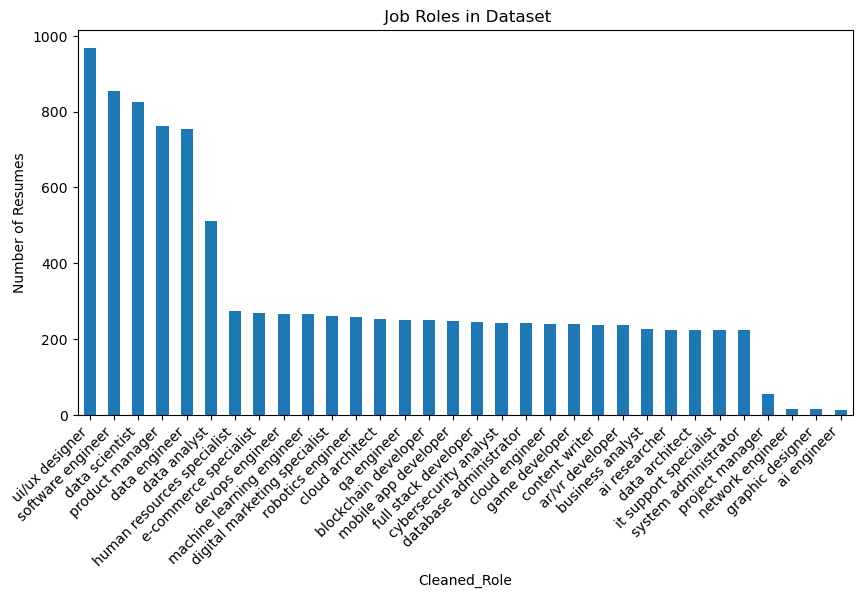

In [143]:
# Count the number of unique roles
unique_roles = df['Cleaned_Role'].nunique()
print(f"Total Unique Job Roles to Predict: {unique_roles}")

# Display the distribution of the roles
role_counts = df['Cleaned_Role'].value_counts()
print("\n--- Distribution of Job Roles ---")
print(role_counts)


role_counts.plot(kind='bar', figsize=(10, 5))
plt.title(" Job Roles in Dataset")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45, ha='right')
plt.show()

In [144]:
# Remove the low-sample classes that don't have enough data
roles_to_drop = ['project manager', 'network engineer', 'graphic designer', 'ai engineer']
df_final = df[~df['Cleaned_Role'].isin(roles_to_drop)].copy()

# Print final distribution and unique count
final_counts = df_final['Cleaned_Role'].value_counts()
print(f"Final Count of Distinct Classes: {len(final_counts)}")
print("\n--- Final Cleaned Role Distribution ---")
print(final_counts)

Final Count of Distinct Classes: 28

--- Final Cleaned Role Distribution ---
Cleaned_Role
ui/ux designer                  967
software engineer               853
data scientist                  825
product manager                 761
data engineer                   754
data analyst                    512
human resources specialist      274
e-commerce specialist           268
devops engineer                 266
machine learning engineer       265
digital marketing specialist    260
robotics engineer               257
cloud architect                 254
qa engineer                     251
blockchain developer            251
mobile app developer            247
full stack developer            246
database administrator          243
cybersecurity analyst           243
cloud engineer                  240
game developer                  239
content writer                  238
ar/vr developer                 237
business analyst                226
ai researcher                   225
data archi

In [145]:
# role to index mapping
role_to_index = {role: idx for idx, role in enumerate(final_counts.index)}
print("\n--- Role to Index Mapping ---")
for role, idx in role_to_index.items():
    print(f"{role}: {idx}")
    


--- Role to Index Mapping ---
ui/ux designer: 0
software engineer: 1
data scientist: 2
product manager: 3
data engineer: 4
data analyst: 5
human resources specialist: 6
e-commerce specialist: 7
devops engineer: 8
machine learning engineer: 9
digital marketing specialist: 10
robotics engineer: 11
cloud architect: 12
qa engineer: 13
blockchain developer: 14
mobile app developer: 15
full stack developer: 16
database administrator: 17
cybersecurity analyst: 18
cloud engineer: 19
game developer: 20
content writer: 21
ar/vr developer: 22
business analyst: 23
ai researcher: 24
data architect: 25
it support specialist: 26
system administrator: 27


In [146]:
df_final.head()

,Role,Resume,Decision,Reason_for_decision,Job_Description,Cleaned_Role
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...,e-commerce specialist
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...,game developer
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...,human resources specialist
3,E-commerce Specialist,Here's a professional resume for Patricia Gray...,select,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...,e-commerce specialist
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...,e-commerce specialist


In [147]:
# split the dataset into training and testing sets with stratifed sampling to maintain class distribution
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_final, test_size=0.2, random_state=42, stratify=df_final['Cleaned_Role'])

In [148]:
# split the training set into training and validation sets with stratified sampling to maintain class distribution
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42, stratify=train_df['Cleaned_Role'])  # 0.25 x 0.8 = 0.2

In [149]:
train_df

,Role,Resume,Decision,Reason_for_decision,Job_Description,Cleaned_Role
508,AR/VR Developer,Here is a professional resume for Maria Wilson...,reject,Lacks hands-on experience with cloud platforms.,"As a AR/VR Developer, you will play a pivotal ...",ar/vr developer
7331,Full Stack Developer,Here is a professional resume for David Martin...,reject,Needs improvement in machine learning algorithms.,Join our team as a Product Manager and leverag...,full stack developer
6848,DevOps Engineer,Here's a professional resume for Natalie Johns...,reject,Insufficient system design expertise for senio...,Be part of a passionate team at the forefront ...,devops engineer
6196,Blockchain Developer,"Here's a sample resume for Michael Kelly, a Bl...",reject,No experience in back-end development.,We're hiring a Blockchain Developer to develop...,blockchain developer
7749,Product Manager,Here's a professional resume for Lisa Clark:\n...,select,Strong technical skills in AI and ML.,We're seeking a talented Product Manager to wo...,product manager
...,...,...,...,...,...,...
9288,software engineer,**eashan gupta**\n**software engineer candidat...,select,"expected_experience : 6-8 years, domains: e-co...",demonstrated strong skills relevant to the rol...,software engineer
9015,data scientist,**tanima saxena**\n**data scientist**\n\nas a ...,select,"expected_experience : 9+ years, domains: healt...",demonstrated strong skills relevant to the rol...,data scientist
3901,Mobile App Developer,Here's a professional resume for Ryan Elliott:...,reject,Insufficient system design expertise for senio...,Join our fast-growing team and help us scale o...,mobile app developer
2662,Cloud Architect,"Here's a sample resume for Nancy Wu, a candida...",select,Solid experience in machine learning and AI.,We need a Cloud Architect to enhance our team'...,cloud architect


In [150]:
print("--- Training Split Ratios ---")
print(train_df['Cleaned_Role'].value_counts(normalize=True).head(5))

print("\n--- Testing Split Ratios ---")
print(test_df['Cleaned_Role'].value_counts(normalize=True).head(5))

--- Training Split Ratios ---
Cleaned_Role
ui/ux designer       0.095963
software engineer    0.084547
data scientist       0.081899
product manager      0.075612
data engineer        0.074785
Name: proportion, dtype: float64

--- Testing Split Ratios ---
Cleaned_Role
ui/ux designer       0.095782
software engineer    0.084864
data scientist       0.081886
product manager      0.075434
data engineer        0.074938
Name: proportion, dtype: float64


In [151]:
df_preprocessed = train_df.copy()

# find unique tokens in the 'Resume' column

In [152]:
# find unique tokens in the 'Resume' column
import re


def get_unique_resume_tokens(text):
    """
    Cleans, extracts emoticons, tokenizes the resume text,
    and returns a sorted list/set of unique tokens.
    """
    if not isinstance(text, str):
        return []
    
    # 1. Remove HTML tags if any exist
    text = re.sub('<[^>]*>', '', text)
    
    # 2. Extract and preserve emoticons (often useful in conversational text)
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', text.lower())
    
    # 3. Replace all non-word characters (punctuation, symbols) with spaces
    # and append the cleaned emoticons back at the end
    text = re.sub('[\W]+', ' ', text.lower()) + ' ' + ' '.join(emoticons).replace('-', '')
    
    # 4. Split text into individual token strings
    tokenized = text.split()
    
    # 5. Extract only unique tokens using a set
    unique_tokens = sorted(list(set(tokenized)))
    
    return unique_tokens

In [153]:
# Test on the first resume
sample_resume = df_preprocessed['Resume'].iloc[0]
unique_tokens = get_unique_resume_tokens(sample_resume)

print(f"Original Text Word Count: {len(sample_resume.split())}")
print(f"Number of Unique Tokens Found: {len(unique_tokens)}")
print("\n--- Sample of 20 Unique Tokens ---")
print(unique_tokens[:20])

Original Text Word Count: 36
Number of Unique Tokens Found: 32

--- Sample of 20 Unique Tokens ---
['555', '5555', 'a', 'and', 'ar', 'c', 'com', 'contact', 'detail', 'developer', 'email', 'expertise', 'for', 'github', 'here', 'highly', 'in', 'information', 'is', 'linkedin']


In [154]:
# Create an empty set to hold all unique vocabulary across the dataset
global_vocabulary = set()

for resume_text in df_preprocessed['Resume']:
    tokens = get_unique_resume_tokens(resume_text)
    global_vocabulary.update(tokens)

print(f"Total Unique Tokens Across All 10,174 Resumes: {len(global_vocabulary)}")

Total Unique Tokens Across All 10,174 Resumes: 15908


In [155]:
import re
from nltk.stem import WordNetLemmatizer

# Initialize the lemmatizer outside the function so it doesn't rebuild on every call
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize_resume_v4(text):
    if not isinstance(text, str):
        return []
    
    # 1. Break the resume into individual lines
    lines = text.split('\n')
    clean_lines = []
    
    # Keywords that indicate a contact, social link, or portfolio line
    contact_keywords = re.compile(
        r'(email|phone|contact|github|linkedin|facebook|twitter|instagram|portfolio|tel|mobile|website|\.com|\.org|\.net)', 
        re.IGNORECASE
    )
    
    for line in lines:
        # If the line contains any contact keyword or structural markdown link syntax, skip it entirely
        if contact_keywords.search(line) or re.search(r'\[.*?\]\(.*?\)', line):
            continue
        clean_lines.append(line)
    
    # Rejoin the filtered lines back into a single string
    processed_text = ' '.join(clean_lines)
    
    # 2. YOUR ORIGINAL TOKENIZER LOGIC
    # Remove HTML tags if any remain
    processed_text = re.sub('<[^>]*>', ' ', processed_text)
    
    # Extract and lower-case emoticons
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', processed_text.lower())
    
    # Keep only alphanumeric character chunks, append emoticons back
    processed_text = re.sub('[\W]+', ' ', processed_text.lower()) + ' ' + ' '.join(emoticons).replace('-', '')
    
    # Split into final token list
    tokenized = processed_text.split()
    
    # 3. LEMMATIZATION STEP
    # Reduce each unique token down to its dictionary base form (lemma)
    # We apply set() again afterwards because different words might map to the same lemma (e.g. 'agencies' and 'agency' both become 'agency')
    unique_tokens = set(tokenized)
    lemmatized_tokens = {lemmatizer.lemmatize(token) for token in unique_tokens}
    
    # Return sorted list of unique lemmas
    return sorted(list(lemmatized_tokens))

In [156]:
messy_header = """
"Here's a professional resume for Patrick Mcclain:

Patrick Mcclain
Human Resources Specialist

Contact Information:

* Phone: (555) 123-4567
* Email: [patrick.mcclain@email.com](mailto:patrick.mcclain@email.com)
* LinkedIn: linkedin.com/in/patrickmcclainhr

Professional Summary:
Results-driven Human Resources Specialist with 5+ years of experience in recruitment, talent acquisition, and HR software implementation. Proven track record of successfully onboarding new employees, resolving conflicts, and improving employee engagement. Skilled in HRIS systems, recruitment marketing, and employee relations. Seeking a challenging role as a Human Resources Specialist where I can leverage my expertise to drive business growth and enhance the employee experience.

Work Experience:

Human Resources Generalist, XYZ Corporation (2018-Present)

* Recruit, interview, and hire top talent to support business growth and expansion
* Implemented and managed HRIS system, resulting in a 30% reduction in recruitment time and a 25% increase in applicant quality
* Designed and delivered comprehensive onboarding programs for new hires, resulting in a 95% retention rate
* Resolved employee conflicts and concerns, improving employee satisfaction and reducing turnover
* Collaborated with management to develop and implement employee recognition and reward programs

Recruitment Coordinator, ABC Agency (2015-2018)

* Coordinated recruitment efforts, including job postings, candidate screenings, and interview scheduling
* Developed and maintained relationships with external recruitment agencies and job boards
* Implemented recruitment software to streamline the hiring process and improve candidate engagement
* Conducted new hire orientations and provided onboarding support to ensure a smooth transition into the company

Education:

* Bachelor's Degree in Human Resources, [University Name] (2015)

Skills:

* HRIS systems (Workday, BambooHR, etc.)
* Recruitment marketing and branding
* Onboarding and employee engagement
* Conflict resolution and employee relations
* Talent acquisition and recruitment
* Employee data analysis and reporting

Achievements:

* Successfully implemented an HRIS system, resulting in a 30% reduction in recruitment time and a 25% increase in applicant quality
* Developed and delivered a comprehensive onboarding program, resulting in a 95% retention rate
* Improved employee satisfaction and reduced turnover by resolving employee conflicts and concerns
* Collaborated with management to develop and implement employee recognition and reward programs, resulting in a 20% increase in employee engagement

Certifications:

* SHRM-CP (Society for Human Resource Management Certified Professional)
* HRCI-CP (HR Certification Institute Certified Professional)

References:
Available upon request.

Note: This is just a sample resume, and you should customize it to fit your specific experience and the job you're applying for. Also, make sure to proofread your resume multiple times for any grammar or formatting errors."

"""

tokens = clean_and_tokenize_resume_v4(messy_header)
print("--- Final Cleaned Vocabulary Remaining ---")
print(tokens)

--- Final Cleaned Vocabulary Remaining ---
['20', '2015', '2018', '25', '30', '5', '95', 'a', 'abc', 'achievement', 'acquisition', 'agency', 'also', 'an', 'analysis', 'and', 'any', 'applicant', 'applying', 'available', 'bachelor', 'bamboohr', 'board', 'branding', 'business', 'by', 'can', 'candidate', 'certification', 'certified', 'challenging', 'collaborated', 'company', 'comprehensive', 'concern', 'conducted', 'conflict', 'coordinated', 'coordinator', 'corporation', 'cp', 'customize', 'data', 'degree', 'delivered', 'designed', 'develop', 'developed', 'drive', 'driven', 'education', 'effort', 'employee', 'engagement', 'enhance', 'ensure', 'error', 'etc', 'expansion', 'experience', 'expertise', 'external', 'fit', 'for', 'formatting', 'generalist', 'grammar', 'growth', 'here', 'hire', 'hiring', 'hr', 'hrci', 'hris', 'human', 'i', 'implement', 'implementation', 'implemented', 'improve', 'improved', 'improving', 'in', 'including', 'increase', 'institute', 'interview', 'into', 'is', 'it', '

In [157]:
from collections import Counter

# Initialize the counter
token_counts = Counter()

# Loop through the Resume column in your DataFrame
for resume_text in df_preprocessed['Resume']:
    # Clean, line-filter, lemmatize, and extract unique tokens
    tokens = clean_and_tokenize_resume_v4(resume_text)
    
    # Update the global vocabulary counts
    token_counts.update(tokens)

print('Vocab-size:', len(token_counts))

Vocab-size: 8808


In [158]:
token_counts.most_common(20)

[('and', 6039),
 ('in', 6038),
 ('experience', 6014),
 ('a', 6011),
 ('with', 5988),
 ('to', 5945),
 ('skill', 5944),
 ('of', 5939),
 ('for', 5905),
 ('summary', 5512),
 ('education', 5426),
 ('team', 5360),
 ('professional', 5352),
 ('s', 5277),
 ('university', 5273),
 ('the', 5243),
 ('2018', 5158),
 ('present', 5119),
 ('collaborated', 5049),
 ('xyz', 5036)]

# encoding each unique token into integers

In [159]:
from dataclasses import dataclass
from typing import Dict, List

# Build token frequency counts from training set only (no data leakage)
token_counts: Counter = Counter()
for text in train_df['Resume']:
    token_counts.update(clean_and_tokenize_resume_v4(text))

print(f"Total unique tokens in training set: {len(token_counts):,}")
print(f"Top-10 tokens: {token_counts.most_common(10)}")

@dataclass
class Vocabulary:
    stoi: Dict[str, int]
    itos: List[str]
    pad_index: int = 0
    unk_index: int = 1

    def __getitem__(self, token: str) -> int:
        return self.stoi.get(token, self.unk_index)

    def __len__(self) -> int:
        return len(self.itos)


def build_vocabulary(token_counts: Counter, min_freq: int = 1) -> Vocabulary:
    specials = ["<pad>", "<unk>"]
    stoi: Dict[str, int] = {t: i for i, t in enumerate(specials)}
    for token, freq in sorted(token_counts.items(), key=lambda x: -x[1]):
        if freq >= min_freq and token not in stoi:
            stoi[token] = len(stoi)
    itos = [t for t, _ in sorted(stoi.items(), key=lambda x: x[1])]
    return Vocabulary(stoi=stoi, itos=itos)


text_vocab = build_vocabulary(token_counts, min_freq=1)

# Role label mapping (alphabetically sorted — deterministic)
role_to_index: Dict[str, int] = {
    role: idx for idx, role in enumerate(sorted(df_final['Cleaned_Role'].unique()))
}
index_to_role: Dict[int, str] = {v: k for k, v in role_to_index.items()}
NUM_CLASSES = len(role_to_index)

print(f"\nVocabulary size  : {len(text_vocab):,}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"\nRole → Index mapping:")
for role, idx in role_to_index.items():
    print(f"  {idx:2d}  {role}")

Total unique tokens in training set: 8,808
Top-10 tokens: [('and', 6039), ('in', 6038), ('experience', 6014), ('a', 6011), ('with', 5988), ('to', 5945), ('skill', 5944), ('of', 5939), ('for', 5905), ('summary', 5512)]

Vocabulary size  : 8,810
Number of classes: 28

Role → Index mapping:
   0  ai researcher
   1  ar/vr developer
   2  blockchain developer
   3  business analyst
   4  cloud architect
   5  cloud engineer
   6  content writer
   7  cybersecurity analyst
   8  data analyst
   9  data architect
  10  data engineer
  11  data scientist
  12  database administrator
  13  devops engineer
  14  digital marketing specialist
  15  e-commerce specialist
  16  full stack developer
  17  game developer
  18  human resources specialist
  19  it support specialist
  20  machine learning engineer
  21  mobile app developer
  22  product manager
  23  qa engineer
  24  robotics engineer
  25  software engineer
  26  system administrator
  27  ui/ux designer


In [160]:
# Test your special tokens
print("Index of '<pad>':", text_vocab["<pad>"])  # Output: 0
print("Index of '<unk>':", text_vocab["<unk>"])  # Output: 1

# Test a real token from the resume vocabulary
example_token = token_counts.most_common(1)[0][0] if len(token_counts) else "<unk>"
print(f"Index of '{example_token}':", text_vocab[example_token])

# Test an unknown word (safely defaults to <unk> / 1 without crashing)
print("Index of a mystery word:", text_vocab["randomxyz123"])  # Output: 1

Index of '<pad>': 0
Index of '<unk>': 1
Index of 'and': 2
Index of a mystery word: 1


In [161]:
# Test a list of tokens using your resume vocabulary
sample_tokens = [token for token, _ in token_counts.most_common(4)] if len(token_counts) else ["<unk>"]

encoded_indices = [text_vocab[token] for token in sample_tokens]

print("Original Tokens:", sample_tokens)
print("Encoded Indices:", encoded_indices)

Original Tokens: ['and', 'in', 'experience', 'a']
Encoded Indices: [2, 3, 4, 5]


In [162]:
# Step 3-A: define the functions for transformation

# Build a stable role-to-index mapping from the cleaned role distribution
role_to_index = {role: idx for idx, role in enumerate(sorted(final_counts.index))}

# 1. Text Transformation Pipeline
# This function takes raw resume text, cleans/tokenizes it, and maps words to vocabulary IDs
text_pipeline = lambda x: [text_vocab[token] for token in clean_and_tokenize_resume_v4(x)]

# 2. Label Transformation Pipeline
# Map a cleaned role name to a numeric class ID
label_pipeline = lambda role: role_to_index.get(role, -1)

In [163]:
label_pipeline("data scientist")  

11

In [164]:
# Get a sample example from your pandas DataFrame split
sample_example = train_df.iloc[0]

# Extract values
sample_text = sample_example['Resume']
sample_label = sample_example['Cleaned_Role']

# Process them through your transformation pipelines
processed_text = text_pipeline(sample_text)
processed_label = label_pipeline(sample_label)

print("--- Text Pipeline Output (First 10 tokens) ---")
print(f"Original Tokens: {clean_and_tokenize_resume_v4(sample_text)[:10]}")  
print(f"Vocabulary IDs:  {processed_text[:10]}") 

print("\n--- Label Pipeline Output ---")
print(f"Original Label: {sample_label} -> Mapped Class ID: {processed_label}")

--- Text Pipeline Output (First 10 tokens) ---
Original Tokens: ['a', 'and', 'ar', 'c', 'detail', 'developer', 'expertise', 'for', 'here', 'highly']
Vocabulary IDs:  [5, 2, 1050, 219, 119, 109, 100, 10, 25, 45]

--- Label Pipeline Output ---
Original Label: ar/vr developer -> Mapped Class ID: 1


In [165]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [166]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# 1. Define the updated collate function for your resume dataset
def collate_batch(batch):
    label_list, text_list, lengths = [], [], []
    
    for sample in batch:
        # Extract fields using your project's exact keys
        # If you haven't mapped 'Cleaned_Role' directly into the dataset object yet, 
        # you can change sample.get('Cleaned_Role') to sample['Role']
        _label = sample.get('Cleaned_Role', sample.get('Role'))
        _text = sample['Resume']
        
        # Run through your text and label translation pipelines
        label_list.append(label_pipeline(_label))
        
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
        
        # Record the true token length of the sequence
        lengths.append(processed_text.size(0))
        
    # CRITICAL FIX: Use torch.int64 for multi-class classification targets
    label_list = torch.tensor(label_list, dtype=torch.int64)
    lengths = torch.tensor(lengths, dtype=torch.int64)
    
    # Pad sequences dynamically using your exact vocabulary pad index (0)
    padded_text_list = nn.utils.rnn.pad_sequence(
        text_list, batch_first=True, padding_value=text_vocab.pad_index
    )
    
    return padded_text_list, label_list, lengths

# 2. Instantiate the DataLoader with your Hugging Face train split
# We set batch_size=4 as requested for testing your batch pipeline
dataloader = DataLoader(
    train_df.to_dict('records'), # Converts pandas rows into list of dictionaries 
    batch_size=4, 
    shuffle=False, 
    collate_fn=collate_batch
)

print("DataLoader initialized successfully!")

DataLoader initialized successfully!


In [167]:
# Grab just the very first batch from your loader
first_batch = next(iter(dataloader))
padded_texts, labels, batch_lengths = first_batch

print("Padded Texts Shape :", padded_texts.shape) 
print("Labels Tensor      :", labels)
print("Original Lengths   :", batch_lengths)

Padded Texts Shape : torch.Size([4, 254])
Labels Tensor      : tensor([ 1, 16, 13,  2])
Original Lengths   : tensor([ 21, 196, 254, 182])


In [168]:
# Transformation pipelines (identical to your notebook)
text_pipeline = lambda x: [text_vocab[t] for t in clean_and_tokenize_resume_v4(x)]
label_pipeline = lambda role: role_to_index[role]


def collate_batch(batch):
    """Tokenises, encodes, and pads a batch of resume dictionaries."""
    label_list, text_list, lengths = [], [], []
    for sample in batch:
        label_list.append(label_pipeline(sample['Cleaned_Role']))
        ids = torch.tensor(text_pipeline(sample['Resume']), dtype=torch.int64)
        text_list.append(ids)
        lengths.append(ids.size(0))

    labels  = torch.tensor(label_list, dtype=torch.int64)
    lengths = torch.tensor(lengths,    dtype=torch.int64)
    padded  = nn.utils.rnn.pad_sequence(
        text_list, batch_first=True, padding_value=text_vocab.pad_index
    )
    return padded, labels, lengths


BATCH_SIZE = 32
train_dl = DataLoader(train_df.to_dict('records'), batch_size=BATCH_SIZE,
                      shuffle=True,  collate_fn=collate_batch)
val_dl   = DataLoader(val_df.to_dict('records'),   batch_size=BATCH_SIZE,
                      shuffle=False, collate_fn=collate_batch)
test_dl  = DataLoader(test_df.to_dict('records'),  batch_size=BATCH_SIZE,
                      shuffle=False, collate_fn=collate_batch)

# Inspect one batch
padded, labels, lengths = next(iter(train_dl))
print(f"Batch padded shape : {padded.shape}   (B × T_max)")
print(f"Labels             : {labels[:8].tolist()}")
print(f"Sequence lengths   : {lengths[:8].tolist()}")

Batch padded shape : torch.Size([32, 237])   (B × T_max)
Labels             : [8, 1, 11, 26, 11, 18, 11, 10]
Sequence lengths   : [171, 161, 208, 199, 193, 164, 237, 176]


In [169]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [170]:
import torch

if torch.cuda.is_available():
    # Get the name of the active GPU device
    device_name = torch.cuda.get_device_name(0)
    print(f"🚀 PyTorch is successfully using: {device_name}")
    
    # Get memory specs to confirm it's your dedicated card
    total_memory = torch.cuda.get_device_properties(0).total_memory
    print(f"💾 Total VRAM available: {total_memory / (1024**3):.2f} GB")
else:
    print("❌ CUDA is not available.")

🚀 PyTorch is successfully using: NVIDIA GeForce RTX 3050 6GB Laptop GPU
💾 Total VRAM available: 6.00 GB


In [171]:
class AttentionLayer(nn.Module):
    """Bahdanau-style additive attention over LSTM hidden states."""
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attention = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        scores = self.attention(lstm_out).squeeze(-1)           # (B, T)
        scores = scores.masked_fill(mask == 0, float('-inf'))   # mask padding
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)    # (B, T, 1)
        context = (lstm_out * weights).sum(dim=1)               # (B, H*2)
        return context


class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int,
        num_classes: int,
        dropout: float = 0.4,
        pad_idx: int = 0,
    ):
        super().__init__()
        self.embedding   = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embed_drop  = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size   = embed_dim,
            hidden_size  = hidden_dim,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if num_layers > 1 else 0.0,
        )

        self.attention  = AttentionLayer(hidden_dim)

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        self.embedding.weight.data[0].fill_(0)          # keep <pad> as zeros
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:  nn.init.orthogonal_(param)
            elif 'bias' in name:  nn.init.zeros_(param)

    def forward(self, text: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        mask      = (text != 0)                                        # (B, T)
        embedded  = self.embed_drop(self.embedding(text))              # (B, T, E)

        packed    = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.clamp(min=1).cpu(),
            batch_first=True, enforce_sorted=False
        )
        lstm_out, _  = self.lstm(packed)
        lstm_out, _  = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)

        mask     = mask[:, :lstm_out.size(1)]                          # align after pack
        context  = self.attention(lstm_out, mask)                      # (B, H*2)
        return self.classifier(context)                                # (B, C)


# Instantiate
model = BiLSTMClassifier(
    vocab_size = len(text_vocab),
    embed_dim  = 128,
    hidden_dim = 256,
    num_layers = 2,
    num_classes= NUM_CLASSES,
    dropout    = 0.4,
    pad_idx    = 0,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

BiLSTMClassifier(
  (embedding): Embedding(8810, 128, padding_idx=0)
  (embed_drop): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=512, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=256, out_features=28, bias=True)
  )
)

Trainable parameters: 3,635,229


In [172]:
EPOCHS   = 20
LR       = 2e-3
PATIENCE = 5

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_dl), epochs=EPOCHS,
    pct_start=0.2, anneal_strategy='cos',
)


def run_epoch(loader: DataLoader, train: bool):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for texts, labels, lengths in loader:
            texts, labels = texts.to(DEVICE), labels.to(DEVICE)
            logits = model(texts, lengths)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total


# ─── Training Loop ────────────────────────────────────────────────────────
history = []
best_val_loss   = float('inf')
best_state      = None
patience_counter= 0

print(f"{'Ep':>3}  {'Tr Loss':>8}  {'Tr Acc':>7}  {'Va Loss':>8}  {'Va Acc':>7}  {'LR':>9}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_dl, train=True)
    va_loss, va_acc = run_epoch(val_dl,   train=False)
    lr_now = scheduler.get_last_lr()[0]
    history.append((tr_loss, tr_acc, va_loss, va_acc))

    print(f"{epoch:>3}  {tr_loss:>8.4f}  {tr_acc:>6.1%}  {va_loss:>8.4f}  {va_acc:>6.1%}  {lr_now:>9.2e}")

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (patience={PATIENCE})")
            break

model.load_state_dict(best_state)
print(f"\n✔  Best validation loss: {best_val_loss:.4f}")

 Ep   Tr Loss   Tr Acc   Va Loss   Va Acc         LR
-------------------------------------------------------
  1    2.5395   27.4%    0.8190   72.2%   3.62e-04
  2    0.6251   76.9%    0.6263   76.8%   1.04e-03
  3    0.4851   83.3%    0.4768   83.7%   1.72e-03
  4    0.4273   86.8%    0.2889   90.7%   2.00e-03
  5    0.2832   91.5%    0.1533   96.0%   1.98e-03
  6    0.1805   94.9%    0.0894   97.7%   1.92e-03
  7    0.1028   97.3%    0.2117   96.0%   1.83e-03
  8    0.1146   97.4%    0.1208   97.6%   1.71e-03
  9    0.0610   98.4%    0.1056   98.1%   1.55e-03
 10    0.0486   98.7%    0.0849   98.4%   1.38e-03
 11    0.0197   99.5%    0.1149   98.0%   1.19e-03
 12    0.0150   99.6%    0.0772   98.6%   9.99e-04
 13    0.0114   99.7%    0.0545   99.0%   8.04e-04
 14    0.0058   99.8%    0.0626   98.7%   6.16e-04
 15    0.0016   99.9%    0.0649   99.1%   4.44e-04
 16    0.0009  100.0%    0.0677   99.0%   2.92e-04
 17    0.0003  100.0%    0.0833   98.9%   1.68e-04
 18    0.0002  100.0%   

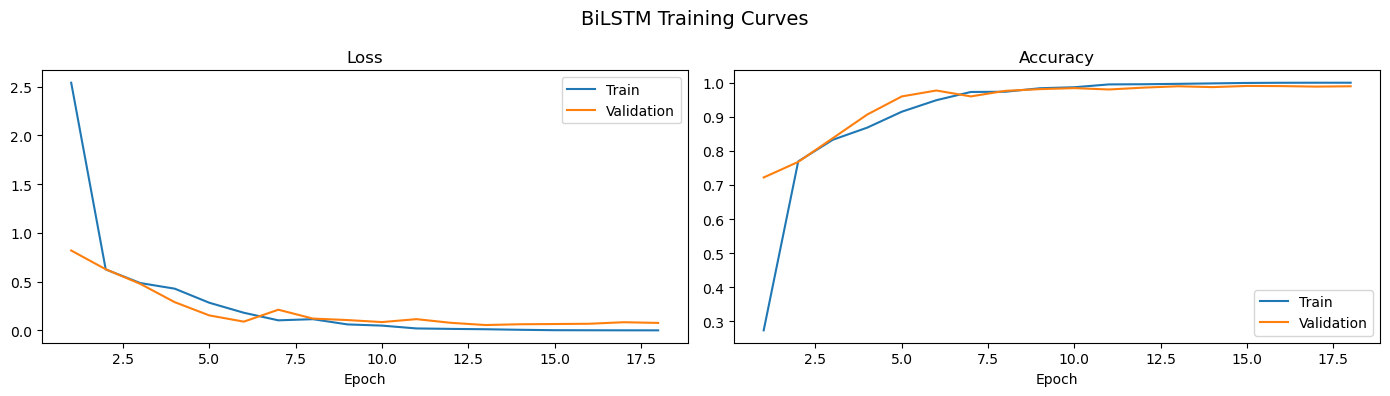

In [173]:
epochs_ran = list(range(1, len(history) + 1))
tr_losses  = [h[0] for h in history]
va_losses  = [h[2] for h in history]
tr_accs    = [h[1] for h in history]
va_accs    = [h[3] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(epochs_ran, tr_losses, label='Train')
ax1.plot(epochs_ran, va_losses, label='Validation')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(epochs_ran, tr_accs,  label='Train')
ax2.plot(epochs_ran, va_accs,  label='Validation')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.suptitle('BiLSTM Training Curves', fontsize=14)
plt.tight_layout(); plt.show()

In [174]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
model.eval()
all_preds, all_labels = [], []
test_loss = 0.0

with torch.no_grad():
    for texts, labels, lengths in test_dl:
        texts, labels = texts.to(DEVICE), labels.to(DEVICE)
        logits     = model(texts, lengths)
        test_loss += criterion(logits, labels).item() * labels.size(0)
        all_preds .extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

test_loss /= len(all_labels)
test_acc   = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.1%}")

label_names = [index_to_role[i] for i in range(NUM_CLASSES)]
print("\n" + classification_report(all_labels, all_preds, target_names=label_names, digits=3))

Test Loss     : 0.0363
Test Accuracy : 99.3%

                              precision    recall  f1-score   support

               ai researcher      1.000     1.000     1.000        45
             ar/vr developer      1.000     1.000     1.000        47
        blockchain developer      1.000     1.000     1.000        50
            business analyst      1.000     1.000     1.000        45
             cloud architect      0.909     0.980     0.943        51
              cloud engineer      0.977     0.896     0.935        48
              content writer      1.000     1.000     1.000        48
       cybersecurity analyst      1.000     1.000     1.000        49
                data analyst      0.990     0.980     0.985       102
              data architect      0.957     1.000     0.978        45
               data engineer      1.000     0.987     0.993       151
              data scientist      0.988     0.994     0.991       165
      database administrator      1.000    

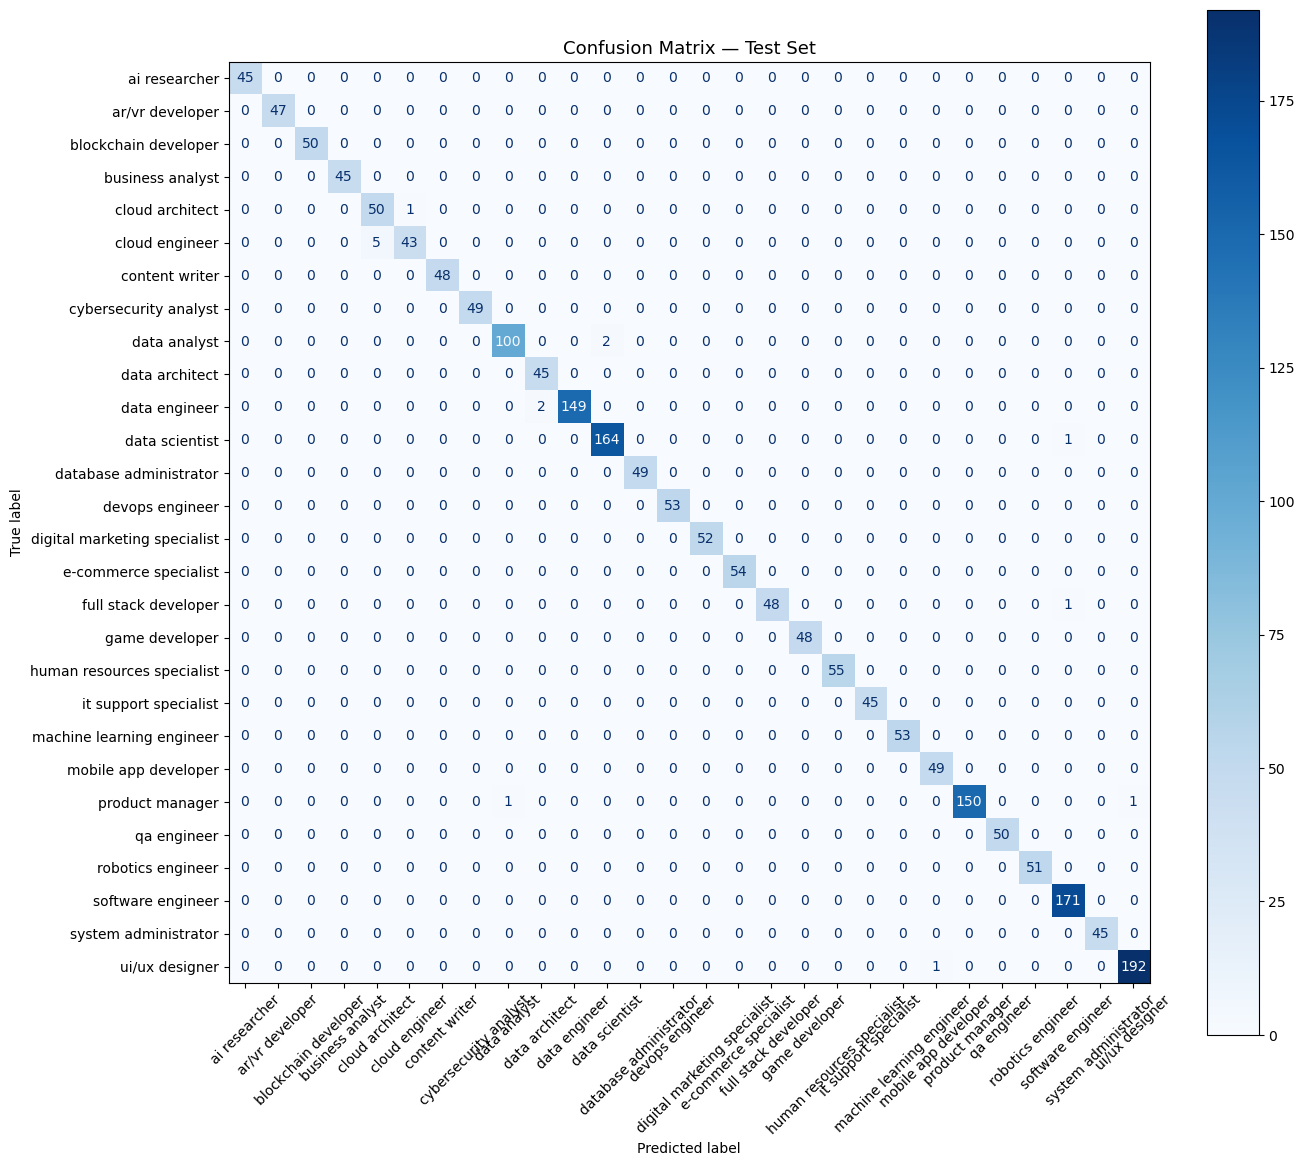


Top-5 confusions (true → predicted):
  5x  cloud engineer                         → cloud architect
  2x  data engineer                          → data architect
  2x  data analyst                           → data scientist
  1x  ui/ux designer                         → mobile app developer
  1x  product manager                        → ui/ux designer


In [175]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=13)
plt.tight_layout(); plt.show()

# Top confusions
errors = [(cm[i,j], label_names[i], label_names[j])
          for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i!=j and cm[i,j]>0]
errors.sort(reverse=True)
if errors:
    print("\nTop-5 confusions (true → predicted):")
    for cnt, t, p in errors[:5]:
        print(f"  {cnt}x  {t:<38} → {p}")

In [176]:
def predict_resume(resume_text: str, top_k: int = 3):
    """Predict job role(s) for a single resume string."""
    model.eval()
    with torch.no_grad():
        ids    = torch.tensor(text_pipeline(resume_text), dtype=torch.int64).unsqueeze(0).to(DEVICE)
        length = torch.tensor([ids.size(1)])
        logits = model(ids, length)
        probs  = torch.softmax(logits, dim=1).squeeze()
        top    = probs.topk(top_k)

    print(f"Resume snippet: \"{resume_text[:90]}...\"")
    print(f"\nTop-{top_k} predictions:")
    for score, idx in zip(top.values.tolist(), top.indices.tolist()):
        bar = '█' * int(score * 35)
        print(f"  {index_to_role[idx]:<38} {score:5.1%}  {bar}")
    print()


predict_resume(
    "Experienced data scientist with 5 years of hands-on work in machine learning, "
    "python, pandas, tensorflow, and deep learning. Built classification models, "
    "performed feature engineering, and validated with cross-validation techniques."
)

predict_resume(
    "Skilled DevOps engineer with expertise in Docker, Kubernetes, Terraform, "
    "and AWS. Designed CI/CD pipelines, automated infrastructure provisioning, "
    "and maintained Prometheus/Grafana monitoring stacks."
)

predict_resume(
    "UI/UX designer with 6 years creating user-centered products in Figma and Sketch. "
    "Conducted user research, wireframing, and usability testing. "
    "Proficient in design systems, typography, and accessibility standards."
)

Resume snippet: "Experienced data scientist with 5 years of hands-on work in machine learning, python, pand..."

Top-3 predictions:
  data scientist                         61.9%  █████████████████████
  machine learning engineer              38.1%  █████████████
  data engineer                           0.0%  

Resume snippet: "Skilled DevOps engineer with expertise in Docker, Kubernetes, Terraform, and AWS. Designed..."

Top-3 predictions:
  devops engineer                        100.0%  ███████████████████████████████████
  mobile app developer                    0.0%  
  cloud architect                         0.0%  

Resume snippet: "UI/UX designer with 6 years creating user-centered products in Figma and Sketch. Conducted..."

Top-3 predictions:
  ui/ux designer                         100.0%  ███████████████████████████████████
  content writer                          0.0%  
  mobile app developer                    0.0%  



In [177]:
checkpoint = {
    'model_state_dict' : model.state_dict(),
    'vocab_stoi'       : text_vocab.stoi,
    'vocab_itos'       : text_vocab.itos,
    'role_to_index'    : role_to_index,
    'index_to_role'    : index_to_role,
    'hyperparams'      : {
        'embed_dim' : 128,
        'hidden_dim': 256,
        'num_layers': 2,
        'dropout'   : 0.4,
        'num_classes': NUM_CLASSES,
    },
}
torch.save(checkpoint, 'bilstm_resume_classifier.pt')
print("Model saved → bilstm_resume_classifier.pt")

# ─── Load and verify ─────────────────────────────────────────────────────────
ckpt = torch.load('bilstm_resume_classifier.pt', map_location='cpu', weights_only=False)
loaded_model = BiLSTMClassifier(
    vocab_size = len(ckpt['vocab_itos']),
    **ckpt['hyperparams'],
    pad_idx    = 0,
)
loaded_model.load_state_dict(ckpt['model_state_dict'])
loaded_model.eval()
print("Model loaded and verified ✓")

Model saved → bilstm_resume_classifier.pt
Model loaded and verified ✓
